# Customer Segmentation Using Unsupervised Learning

## DevelopersHub Corporation
### Data Science & Analytics Internship


## Problem Statement

Businesses serve customers with different spending behaviors and purchasing patterns.

Treating all customers the same leads to ineffective marketing and reduced profitability.

The goal of this project is to identify distinct customer groups using clustering techniques and develop targeted marketing strategies for each group.

## Objectives

- Understand customer demographics and spending behavior
- Perform exploratory data analysis (EDA)
- Apply K-Means clustering
- Determine optimal number of clusters
- Visualize customer segments using PCA
- Develop marketing strategies for each segment

## Import Libraries

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

import warnings

warnings.filterwarnings("ignore")

## Dataset Description

The dataset contains customer information including:

- Customer ID
- Gender
- Age
- Annual Income
- Spending Score

Spending Score is assigned by the mall based on customer purchasing behavior.

The objective is to group customers into meaningful segments for strategic marketing.

## Loading DataSt

In [15]:
df = pd.read_csv("Mall_Customers.csv")

In [16]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## DataSet Overview

In [17]:
df.shape

(200, 5)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [19]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Data Cleaning

### Missing Values

In [20]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Duplicates

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.drop_duplicates(inplace=True)

# Exploratory Data Analysis(EDA)

### Customer Gender Distribution

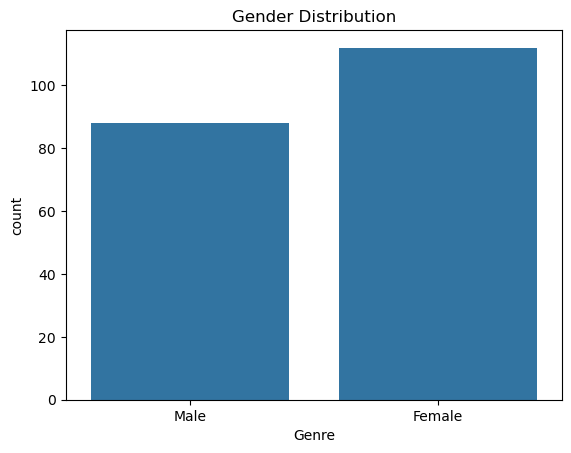

In [25]:
sns.countplot(
    x='Genre',
    data=df
)

plt.title("Gender Distribution")

plt.show()

### Age Distribution

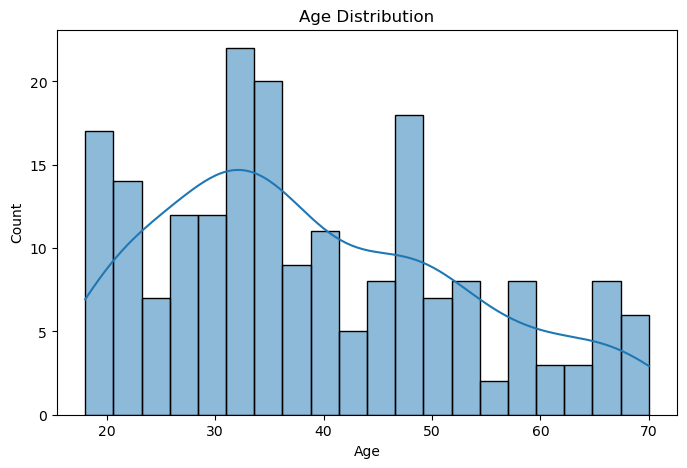

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

### Annual Income Distribution

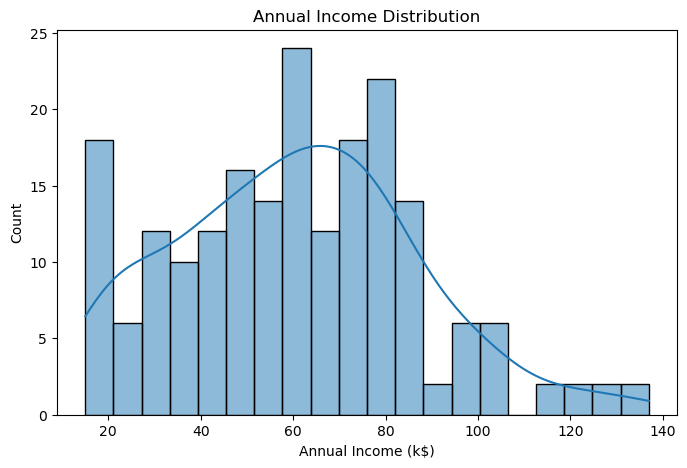

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Annual Income (k$)'],
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution")

plt.show()

### Spending Score Distribution

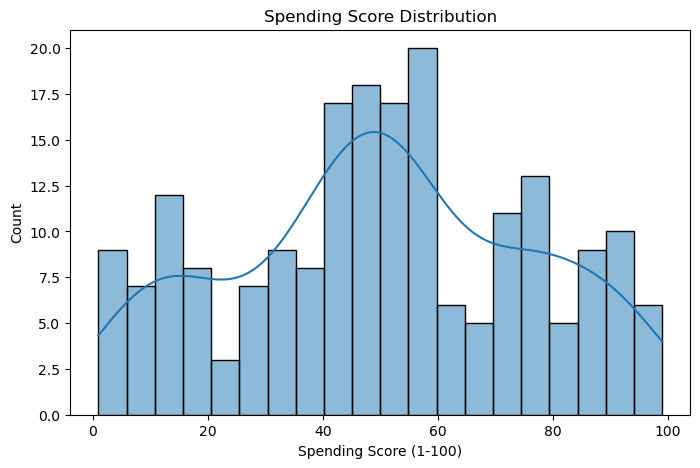

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Spending Score (1-100)'],
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution")

plt.show()

### Age vs Spending Score

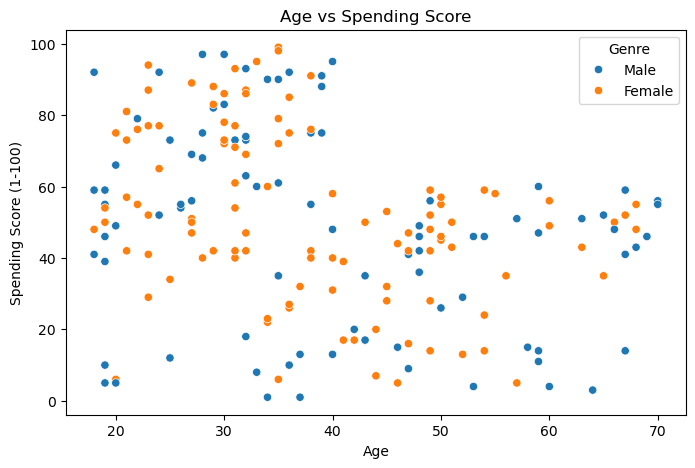

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(

    x='Age',

    y='Spending Score (1-100)',

    hue='Genre',

    data=df
)

plt.title("Age vs Spending Score")

plt.show()

### Income vs Spending Score

### Spending Score by Gender

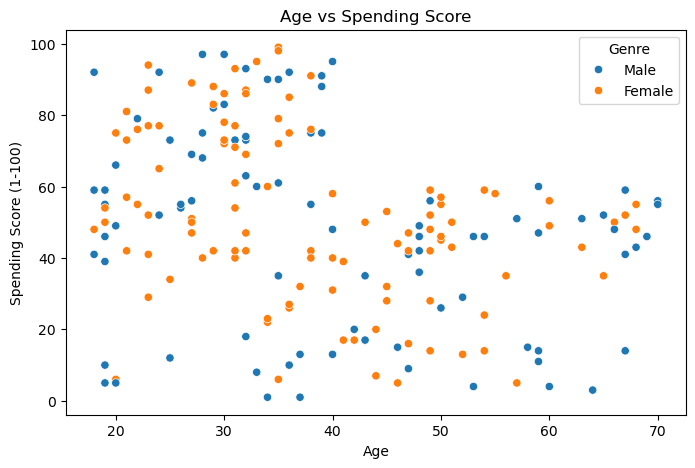

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(

    x='Age',

    y='Spending Score (1-100)',

    hue='Genre',

    data=df
)

plt.title("Age vs Spending Score")

plt.show()

### Correlation Heatmap

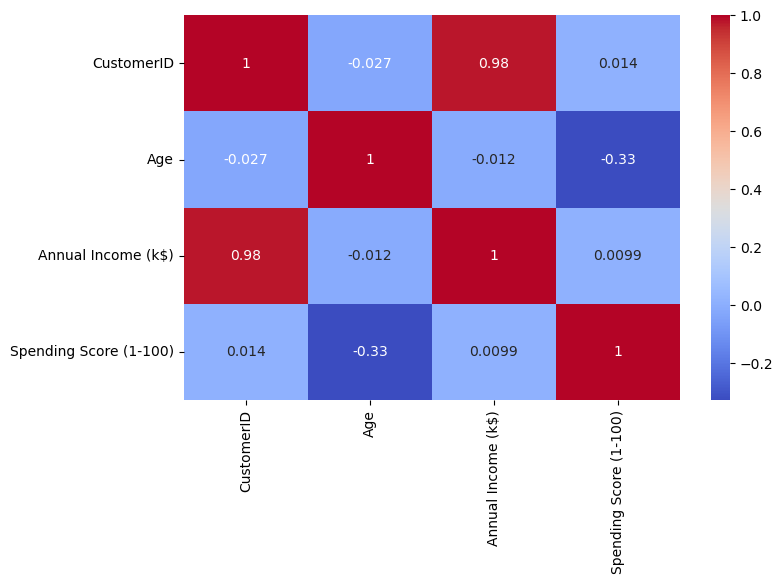

In [32]:
plt.figure(figsize=(8,5))

sns.heatmap(

    df.select_dtypes(include=np.number)
    .corr(),

    annot=True,

    cmap='coolwarm'
)

plt.show()

## Pairplot

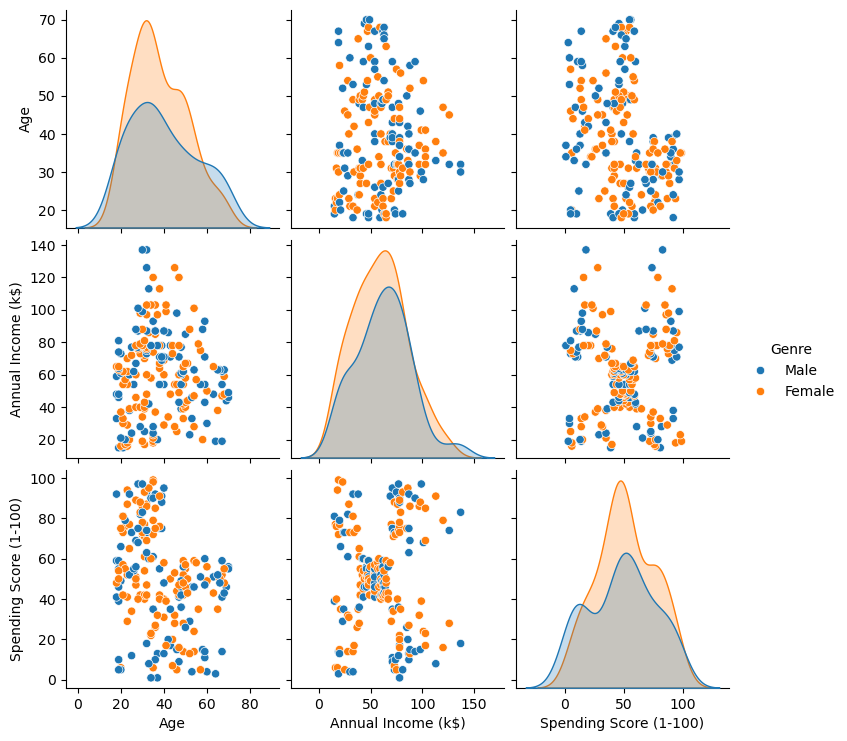

In [33]:
sns.pairplot(

    df[
        ['Age',
         'Annual Income (k$)',
         'Spending Score (1-100)',
         'Genre']
    ],

    hue='Genre'
)

plt.show()

# Feature Selection

In [34]:
X = df[
    [
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
]

# Feature Scaling

In [35]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Elbow Method

In [36]:
wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    wcss.append(
        km.inertia_
    )

## Plot Elbow Curve

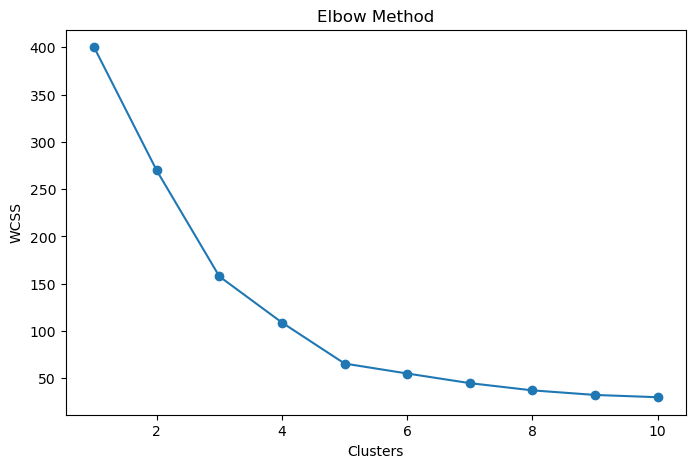

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

### Observation

The elbow point appers around K=5.

Therefore, 5 clusters are chosen.

# K-Means Clustering

In [39]:
kmeans = KMeans(

    n_clusters=5,

    random_state=42,

    n_init=10
)

df['Cluster'] = kmeans.fit_predict(
    X_scaled
)

# Silhouette Score

In [40]:
score = silhouette_score(

    X_scaled,

    df['Cluster']
)

print(
    "Silhouette Score:",
    score
)

Silhouette Score: 0.5546571631111091


# Cluster Visualization

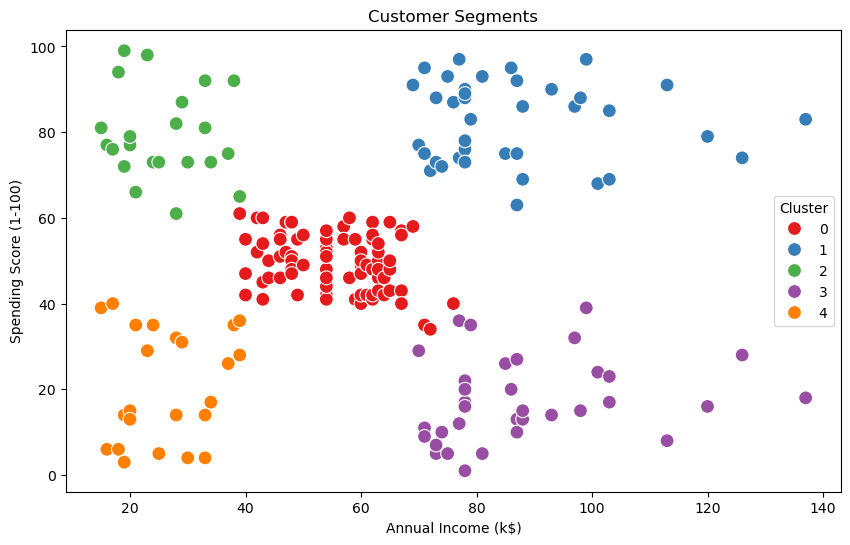

In [41]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    x='Annual Income (k$)',

    y='Spending Score (1-100)',

    hue='Cluster',

    palette='Set1',

    data=df,

    s=100
)

plt.title("Customer Segments")

plt.show()

# Cluster Summary

In [42]:
cluster_summary = df.groupby(
    'Cluster'
).mean(numeric_only=True)

cluster_summary

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


# PCA Visualization

In [43]:
pca = PCA(
    n_components=2
)

In [44]:
components = pca.fit_transform(
    X_scaled
)

In [45]:
pca_df = pd.DataFrame(

    components,

    columns=[
        'PC1',
        'PC2'
    ]
)

pca_df['Cluster'] = df['Cluster']

# PCA Plot

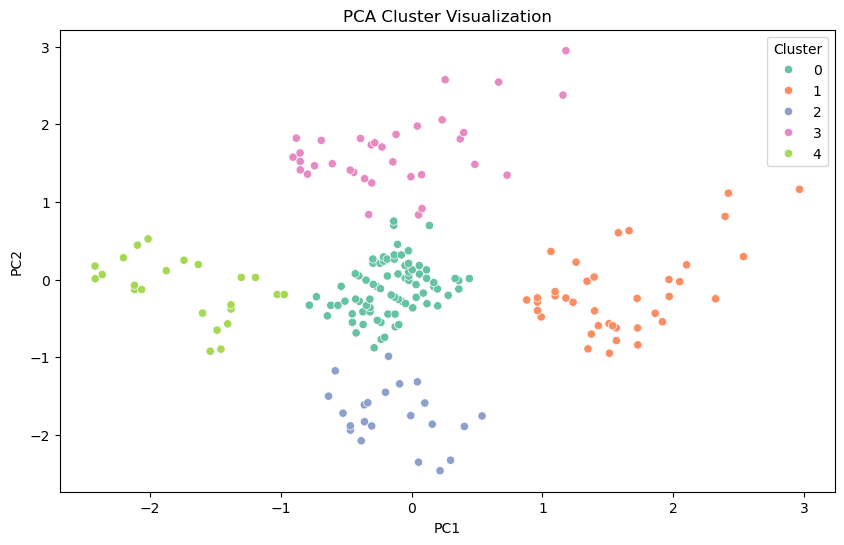

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    x='PC1',

    y='PC2',

    hue='Cluster',

    data=pca_df,

    palette='Set2'
)

plt.title("PCA Cluster Visualization")

plt.show()

# Segment interpretation

Cluster 0
High Income + High Spending

Cluster 1
High Income + Low Spending

Cluster 2
Low Income + High Spending

Cluster 3
Low Income + Low Spending

Cluster 4
Average Customers

# Marketing Strategies

### Cluster 0

High Income + High Spending 
- VIP Membership
- Premium Products
- Exclusive Events
- Loyalty Rewards

### Cluster 1

High Income + Low Spending

- Personalized Discounts
- Premium Product Recommendations
- Email Campaigns

### Cluster 2

Low Income + High Spending

- Seasonal Offers
- Discounts
- Bundle Packages

### Cluster 3

Low Income + Low Spending

- Budget-Friendly Products
- Mass Marketing Campaigns

### Cluster 4

Average Customers

- Cross-Selling
- Retention Campaigns
- Loyalty Programs

# Business insights 

## Key Findings

1. Five distinct customer groups were identified.

2. Income alone does not determine spending behavior.

3. Some customers spend heavily despite lower income.

4. Personalized marketing can increase conversions and customer satisfaction.

## Conclusion

Customer segmentation was successfully performed using K-Means Clustering.

The Elbow Method identified five optimal customer groups.

PCA was used to visualize cluster separation.

Each customer segment displayed unique spending behavior and requires a separate marketing strategy.

This analysis can help businesses improve customer targeting, increase sales, and optimize marketing expenditure.